In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.linalg import solve
from mpl_toolkits.mplot3d import axes3d
import matplotlib.cm as cm

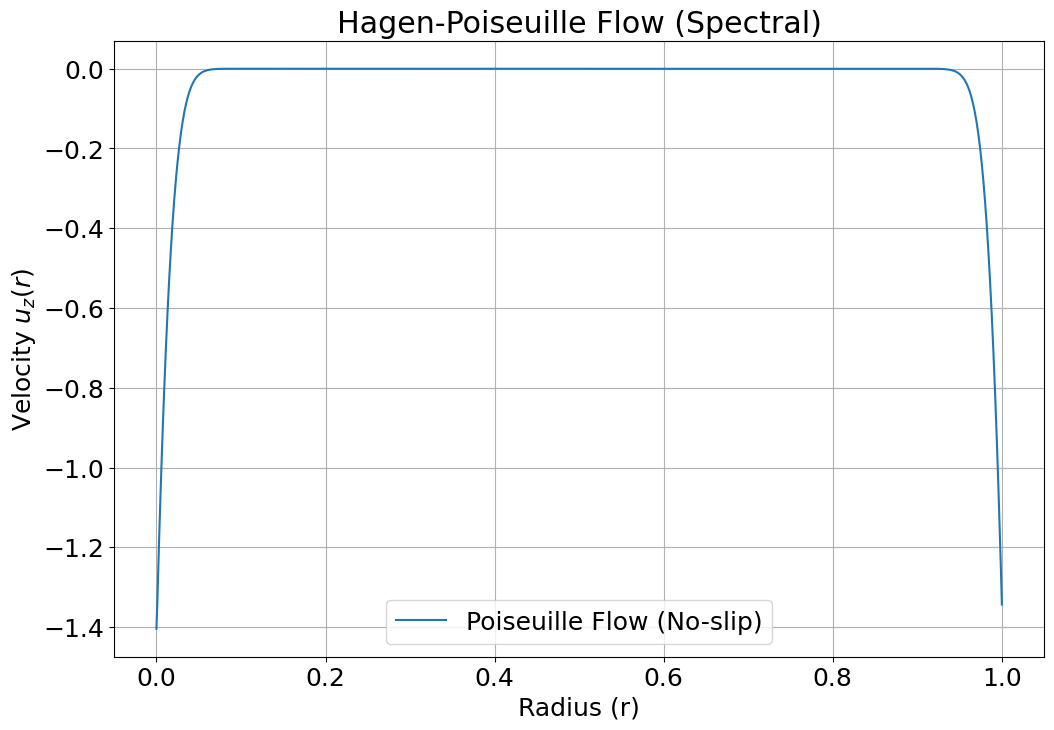

In [21]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams.update({'font.size': 18})

# Parameters
R = 1  # Pipe radius
L = 100  # Length of domain
N = 1000  # Number of discretization points
nu = 0.25  # Viscosity
G = -1  # Pressure gradient

# Discretize radial domain
dx = L / N
r = np.linspace(0, R, N)

# Define discrete wavenumbers for spectral method
kappa = 2 * np.pi * np.fft.fftfreq(N, d=dx)

# Initial velocity profile (zero initial velocity)
u0 = np.zeros_like(r)
u0hat = np.fft.fft(u0)

# Convert to real and imaginary parts
u0hat_ri = np.concatenate((u0hat.real, u0hat.imag))

# Time discretization
dt = 0.1
t = np.arange(0, 10, dt)

# RHS for Hagen-Poiseuille flow in Fourier space
def rhsPoiseuille(u_hat_ri, t, kappa, nu, G):
    u_hat = u_hat_ri[:N] + (1j) * u_hat_ri[N:]
    d_u_hat = -nu * (np.power(kappa, 2)) * u_hat + (G / nu) * np.ones_like(u_hat)
    d_u_hat_ri = np.concatenate((d_u_hat.real, d_u_hat.imag)).astype('float64')
    return d_u_hat_ri

# Solve in Fourier space
u_hat_ri = odeint(rhsPoiseuille, u0hat_ri, t, args=(kappa, nu, G))
u_hat = u_hat_ri[:, :N] + (1j) * u_hat_ri[:, N:]

# Inverse Fourier Transform to get velocity profile
u = np.zeros_like(u_hat)

for k in range(len(t)):
    u[k, :] = np.fft.ifft(u_hat[k, :])

u = u.real

# Plotting final velocity profile
plt.plot(r, u[-1, :], label='Poiseuille Flow (No-slip)')
plt.xlabel('Radius (r)')
plt.ylabel('Velocity $u_z(r)$')
plt.title('Hagen-Poiseuille Flow (Spectral)')
plt.legend()
plt.grid()
plt.show()

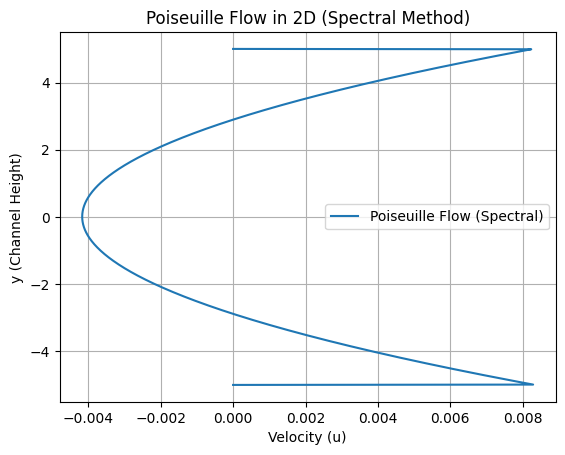

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftfreq, fft, ifft
from scipy.integrate import odeint

# Parameters
nu = 1.0       # Kinematic viscosity
L = 10.0       # Channel height
N = 1000       # Number of discretization points
dpdx = 1.0    # Pressure gradient
G = dpdx / nu  # Forcing term

dy = L / N
y = np.linspace(-L / 2, L / 2, N)

# Define discrete wavenumbers for Fourier transform
kappa = 2 * np.pi * fftfreq(N, d=dy)

# Initial condition (velocity profile, starting at zero)
u0 = np.zeros_like(y)
u0hat = fft(u0)

# Treating Fourier coefficients as a real-valued problem
u0hat_ri = np.concatenate((u0hat.real, u0hat.imag))

# Right-hand side for Poiseuille flow (spectral space)
def rhsPoiseuille(u_hat_ri, t, kappa, G):
    u_hat = u_hat_ri[:N] + (1j) * u_hat_ri[N:]
    d_u_hat = -(G / (kappa**2 + 1e-6))  # Avoid division by zero at kappa=0
    d_u_hat[0] = 0  # Ensure no flow at kappa=0 (no net flux)
    d_u_hat_ri = np.concatenate((d_u_hat.real, d_u_hat.imag)).astype('float64')
    return d_u_hat_ri

# Simulate (not time-dependent but solve in Fourier space)
u_hat_ri = odeint(rhsPoiseuille, u0hat_ri, [0, 1], args=(kappa, G))
u_hat = u_hat_ri[-1, :N] + 1j * u_hat_ri[-1, N:]

# Inverse Fourier Transform to get velocity in physical space
u = ifft(u_hat).real

# Apply no-slip condition (manually enforce u = 0 at boundaries)
u[0] = 0
u[-1] = 0

# Plotting
plt.plot(u, y, label='Poiseuille Flow (Spectral)')
plt.ylabel('y (Channel Height)')
plt.xlabel('Velocity (u)')
plt.title('Poiseuille Flow in 2D (Spectral Method)')
plt.legend()
plt.grid()
plt.show()


In [12]:
import numpy as np
from scipy.fft import fft, ifft, fftfreq
import scipy as sci
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
L = 0.000005  #m
N = 128  #number of grid points
omega = 1.4833   #s^-1 = BPM/60
nu = 0.0032965  #Pa*s
rho = 1050  #kg*m^-3
G = -11465.69  #Pa = 133*mmHg
T = 500  #final time
dt = 0.1  #time step size

#+ 8399.31

# Grid in physical space
y = np.linspace(-L, L, N)
dy = y[1] - y[0]

#grid in fourier space
k = sci.fft.fftfreq(N, d=dy) * 2 * np.pi

#initial velocity profile, u_0 = 0
u0 = np.zeros(N)

#fourier transform of initial velocity
u0_hat = sci.fft.fft(u0)

def pressure(w, t):
    return np.sin(w*t)**2

#defines the RHS of the ODE in Fourier space
def navierstokes_fourier(t, u_hat):
    #compute the second derivative (laplacian) in fourier space
    u_y2_hat = -(k**2) * u_hat
    
    #define du_hat/dt = G/rho * sin^2(wt) + nu*(-k^2 u_hat)
    du_hat_dt = (G * pressure(omega, t)) / rho + nu * u_y2_hat
    return du_hat_dt

#uses RK45 to solve the 1st order time ODE
solution = solve_ivp(navierstokes_fourier, [0, T], u0_hat, method = 'RK45', t_eval = np.arange(0, T, dt))

#inverse fourier transform to get the velocity in real space
u_solution = np.array([sci.fft.ifft(u_hat).real for u_hat in solution.y.T])

u_max = np.zeros(len(solution.t))

for i in range(len(solution.t)):
    u_solution[i] -= np.min(u_solution[i])
    u_max[i] = np.max(u_solution[i])

# Visualization of the solution
plt.figure(figsize=(8, 6))
for i in range(0, len(solution.t), len(solution.t) // 100):
    plt.plot(u_solution[i], y, label=f't = {solution.t[i]:.2f}')

plt.ylabel('y')
plt.xlabel('Velocity u(y, t)')
plt.title('Poiseuille Flow Evolution in a Channel')
#plt.legend()
plt.grid(True)
plt.show()



KeyboardInterrupt: 

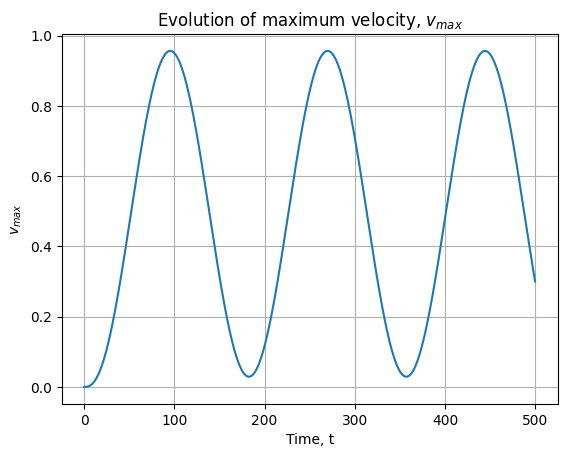

In [7]:
plt.plot(solution.t, u_max)
plt.title('Evolution of maximum velocity, $v_{max}$')
plt.xlabel('Time, t')
plt.ylabel('$v_{max}$')
plt.grid()
plt.show()

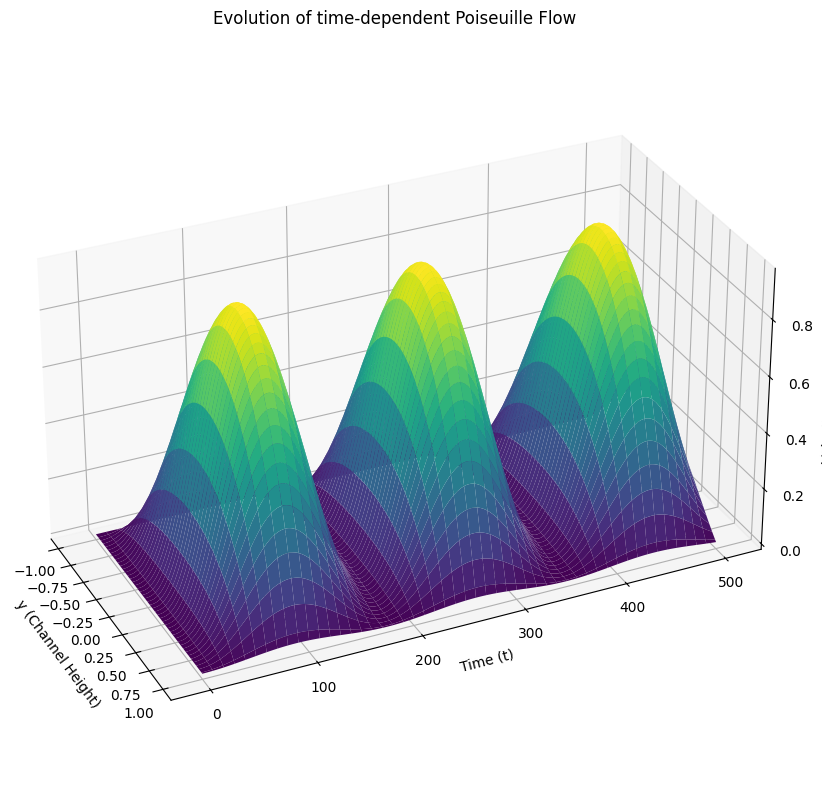

In [8]:
from mpl_toolkits.mplot3d import Axes3D

# 3D Visualization of the solution
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

T_mesh, Y_mesh = np.meshgrid(solution.t, y)

ax.plot_surface(Y_mesh, T_mesh, u_solution.T, cmap='viridis')
ax.view_init(elev=30, azim=335)
ax.set_box_aspect([1, 2, 1])


ax.set_xlabel('y (Channel Height)')
ax.set_ylabel('Time (t)')
ax.set_zlabel('Velocity u(y, t)')
ax.set_title('Evolution of time-dependent Poiseuille Flow')

plt.show()


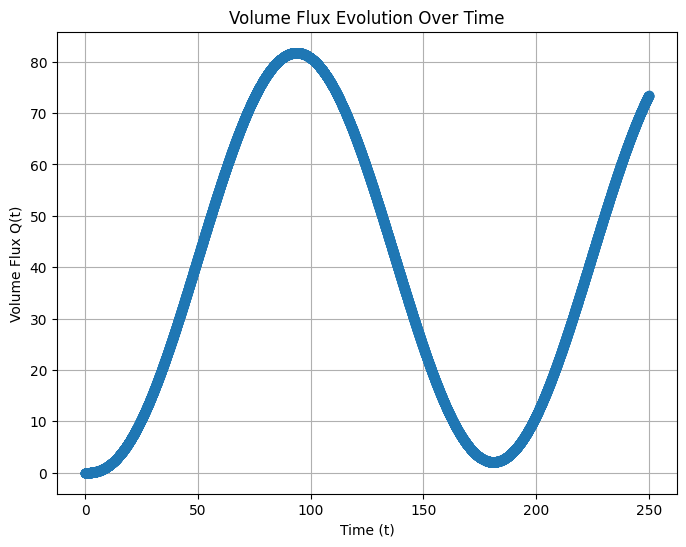

In [42]:
from scipy.integrate import simpson

# Calculate volume flux over time
flux = [simpson(u_solution[i]) for i in range(len(solution.t))]

# Plotting the volume flux over time
plt.figure(figsize=(8, 6))
plt.plot(solution.t, flux, '-o')
plt.xlabel('Time (t)')
plt.ylabel('Volume Flux Q(t)')
plt.title('Volume Flux Evolution Over Time')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from scipy.fft import fft, ifft, fftfreq
import scipy as sci
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
L = 0.005  #milli meters
N = 1024  #number of grid points
omega = 1.4833   #s^-1 = BPM/60
nu = 0.0032965  #Pa*s
rho = 1050  #kg*m^-3
G = -12650.69  #Pa = 133*mmHg
T = 10  #final time
dt = 0.0001  #time step size

# Grid in physical space
y = np.linspace(-L, L, N)
dy = y[1] - y[0]

#grid in fourier space
k = sci.fft.fftfreq(N, d=dy) * 2 * np.pi

#initial velocity profile, u_0 = 0
u0 = np.zeros(N)

#fourier transform of initial velocity
u0_hat = sci.fft.fft(u0)

def pressure(w, t):
    return np.sin(w*t)**2

#defines the RHS of the ODE in Fourier space
def navierstokes_fourier(t, u_hat):
    #compute the second derivative (laplacian) in fourier space
    u_y2_hat = -(k**2) * u_hat
    
    #define du_hat/dt = G/rho * sin^2(wt) + nu*(-k^2 u_hat)
    du_hat_dt = (G * pressure(omega, t)) / rho + nu * u_y2_hat
    return du_hat_dt

#uses RK45 to solve the 1st order time ODE
solution = solve_ivp(navierstokes_fourier, [0, T], u0_hat, method = 'BDF', t_eval = np.arange(0, T, dt))

#inverse fourier transform to get the velocity in real space
u_solution = np.array([sci.fft.ifft(u_hat).real for u_hat in solution.y.T])

u_max = np.zeros(len(solution.t))

for i in range(len(solution.t)):
    u_solution[i] -= np.min(u_solution[i])
    u_max[i] = np.max(u_solution[i])

# Visualization of the solution
plt.figure(figsize=(8, 6))
for i in range(0, len(solution.t), len(solution.t) // 100):
    plt.plot(u_solution[i], y, label=f't = {solution.t[i]:.2f}')

plt.ylabel('y')
plt.xlabel('Velocity u(y, t)')
plt.title('Poiseuille Flow Evolution in a Channel')
#plt.legend()
plt.grid(True)
plt.show()



In [ ]:
plt.plot(solution.t, u_max)
plt.title('Evolution of maximum velocity, $v_{max}$')
plt.xlabel('Time, t')
plt.ylabel('$v_{max}$')
plt.grid()
plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# 3D Visualization of the solution
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

T_mesh, Y_mesh = np.meshgrid(solution.t, y)

ax.plot_surface(Y_mesh, T_mesh, u_solution.T, cmap='plasma')
ax.view_init(elev=30, azim=335)
ax.set_box_aspect([1, 2, 1])


ax.set_xlabel('y (Channel Height)')
ax.set_ylabel('Time (t)')
ax.set_zlabel('Velocity u(y, t)')
ax.set_title('Evolution of time-dependent Poiseuille Flow')

plt.show()